# Is average spend per card really falling?
### Credit card portfolio, January to June: a fact-based diagnosis

**Question from leadership:** average spend per active card seems to have dropped meaningfully over the last six months. Before acting, we need to know whether that drop is real.

**Data:** the four summary tables provided (portfolio trend, June spend distribution, June spend by card age ("vintage"), and category mix). They have been transcribed into `data/raw/`.

---

### Short answer

| Question | Answer |
|---|---|
| **Q1. Real or mechanical?** | **Mostly mechanical.** Average spend per active card fell **16%** (₹50.0K to ₹42.0K), but **total spend rose 18%**. About **69%** of the drop comes from more zero-spend cards in the base, caused by fast new-card acquisition. Among cards that actually spend, the average fell only **5%**, and that softening only began in **May and June**. That part is real and worth watching. |
| **Q2. Biggest driver?** | **New cards that haven't started spending yet.** Active cards grew 40% while the zero-spend share went from 12% to 22%. Cards under 3 months old are 28% of the base but only 13% of spend, and their **median spend is ₹0**. |
| **Q3. CEO summary** | See `reports/CEO_summary.pptx` and the last section of this notebook. |

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.load_data import load_tables
from src import metrics as M
from src import plots as P

P.set_style()
pd.set_option("display.float_format", "{:,.2f}".format)

tables = load_tables()          # also checks that every share table sums to 100%
t1, t2, t3, t4 = (tables[k] for k in ["t1", "t2", "t3", "t4"])
t1

,month,active_cards_k,new_cards_added_k,zero_spend_pct,total_spend_cr
0,Jan,820,60,12,4100
1,Feb,850,75,14,4165
2,Mar,910,95,15,4460
3,Apr,980,110,18,4606
4,May,1060,130,20,4770
5,Jun,1150,145,22,4830


## 1. Reproduce the KPI, then look at what sits underneath it

The KPI is `total spend ÷ active cards`. Two things can move it:

* the **numerator**: how much customers spend
* the **denominator**: how many cards are counted, including cards that spent nothing

So track it next to **spend per *spending* card**, which counts only cards that actually transacted (`active × (1 − zero-spend %)`).

In [2]:
pm = M.portfolio_metrics(t1)
view = pm[["month", "active_cards", "spending_cards", "zero_spend_pct", "total_spend_cr",
           "avg_spend_per_active_card", "avg_spend_per_spending_card"]]
view.style.format({"active_cards": "{:,.0f}", "spending_cards": "{:,.0f}", "zero_spend_pct": "{:.0f}%",
                   "total_spend_cr": "₹{:,.0f} Cr", "avg_spend_per_active_card": "₹{:,.0f}",
                   "avg_spend_per_spending_card": "₹{:,.0f}"}).hide(axis="index")

month,active_cards,spending_cards,zero_spend_pct,total_spend_cr,avg_spend_per_active_card,avg_spend_per_spending_card
Jan,"820,000","721,600",12%,"₹4,100 Cr","₹50,000","₹56,818"
Feb,"850,000","731,000",14%,"₹4,165 Cr","₹49,000","₹56,977"
Mar,"910,000","773,500",15%,"₹4,460 Cr","₹49,011","₹57,660"
Apr,"980,000","803,600",18%,"₹4,606 Cr","₹47,000","₹57,317"
May,"1,060,000","848,000",20%,"₹4,770 Cr","₹45,000","₹56,250"
Jun,"1,150,000","897,000",22%,"₹4,830 Cr","₹42,000","₹53,846"


In [3]:
M.growth_summary(pm).to_frame().style.format("{:+.1%}")

,jan_to_jun_change
active_cards,+40.2%
spending_cards,+24.3%
zero_spend_cards,+157.1%
total_spend_inr,+17.8%
avg_spend_per_active_card,-16.0%
avg_spend_per_spending_card,-5.2%


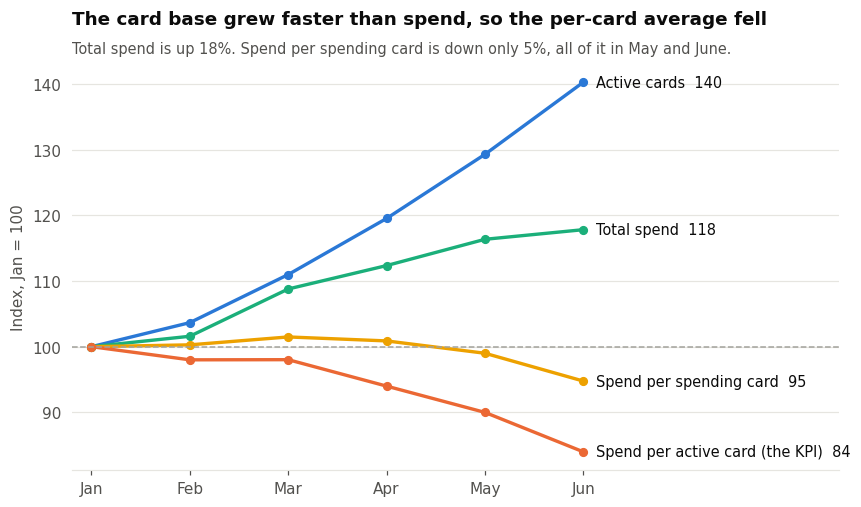

In [4]:
idx = pm.set_index("month")
series = [
    ("Active cards", "active_cards", P.BLUE),
    ("Total spend", "total_spend_inr", P.AQUA),
    ("Spend per spending card", "avg_spend_per_spending_card", P.YELLOW),
    ("Spend per active card (the KPI)", "avg_spend_per_active_card", P.ORANGE),
]
fig, ax = plt.subplots(figsize=(9, 4.8))
x = range(len(idx))
for label, col, color in series:
    y = idx[col] / idx[col].iloc[0] * 100
    ax.plot(x, y, color=color, lw=2.2, marker="o", ms=5)
    ax.annotate(f"{label}  {y.iloc[-1]:.0f}", (len(idx) - 1, y.iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9.5, color=P.INK)
ax.axhline(100, color=P.GREY, lw=1, ls="--")
ax.set_xticks(list(x), idx.index.astype(str))
ax.set_xlim(-0.2, len(idx) - 1 + 2.6)
ax.set_ylabel("Index, Jan = 100")
ax.set_title("The card base grew faster than spend, so the per-card average fell", pad=26)
P.subtitle(ax, "Total spend is up 18%. Spend per spending card is down only 5%, all of it in May and June.")
P.save(fig, "fig1_indexed_trend"); plt.show()

**What this shows**

* Total spend did not fall; it **grew 18%**. The business is not shrinking.
* Active cards grew **40%**, faster than spend, so the per-card average fell. That is a denominator effect.
* Spend per *spending* card was **flat from January to April** (about ₹57K) and fell about 6% only in May and June. That's the part that could be a real change in behaviour.

## 2. Decompose the ₹8,000 drop

The KPI can be written as a product of two factors:

$$\text{spend per active card} = \underbrace{(1-\text{zero-spend share})}_{\text{activation}} \times \underbrace{\text{spend per spending card}}_{\text{engagement}}$$

We split the change between the two factors with a symmetric split, so the answer doesn't depend on which factor we change first.

In [5]:
bridge = M.decompose_avg_change(pm)
bridge.to_frame("value").style.format(lambda v: f"{v:.0%}" if abs(v) < 1.5 else f"₹{v:,.0f}")

,value
start_avg,"₹50,000"
zero_spend_dilution,"₹-5,533"
lower_spend_per_spending_card,"₹-2,467"
end_avg,"₹42,000"
total_change,"₹-8,000"
share_from_zero_spend,69%
share_from_spend_per_spender,31%


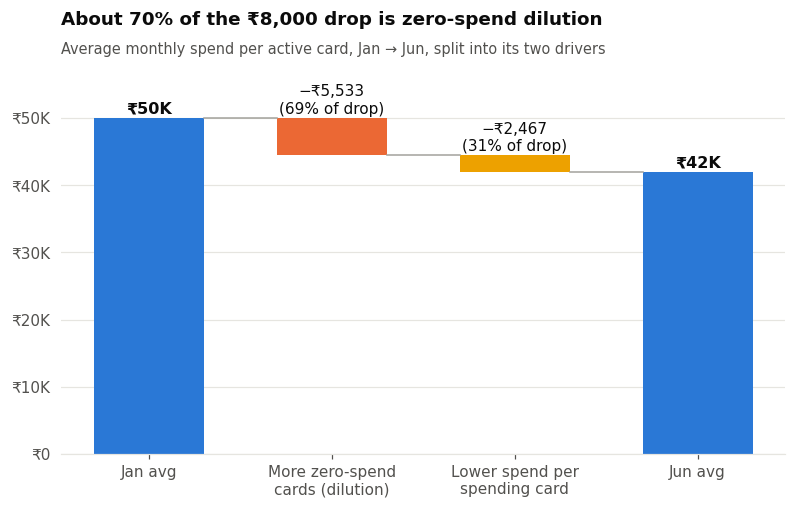

In [6]:
steps = [("Jan avg", bridge.start_avg, "total"),
         ("More zero-spend\ncards (dilution)", bridge.zero_spend_dilution, "step"),
         ("Lower spend per\nspending card", bridge.lower_spend_per_spending_card, "step"),
         ("Jun avg", bridge.end_avg, "total")]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
level = 0
for i, (lab, val, kind) in enumerate(steps):
    if kind == "total":
        ax.bar(i, val, color=P.BLUE, width=0.6)
        ax.text(i, val + 700, P.inr(val), ha="center", fontsize=10.5, fontweight="bold")
        level = val
    else:
        color = P.ORANGE if i == 1 else P.YELLOW
        ax.bar(i, val, bottom=level, color=color, width=0.6)
        share = val / bridge.total_change
        ax.text(i, level + 700, f"−₹{abs(val):,.0f}\n({share:.0%} of drop)", ha="center", fontsize=10)
        level += val
    if i < len(steps) - 1:
        ax.plot([i + 0.3, i + 0.7], [level, level], color=P.GREY, lw=1)
ax.set_xticks(range(len(steps)), [s[0] for s in steps])
ax.set_ylim(0, 58000)
P.inr_axis(ax)
ax.set_title("About 70% of the ₹8,000 drop is zero-spend dilution", pad=26)
P.subtitle(ax, "Average monthly spend per active card, Jan → Jun, split into its two drivers")
P.save(fig, "fig2_waterfall"); plt.show()

**Month by month**: has the mix of drivers changed over time?

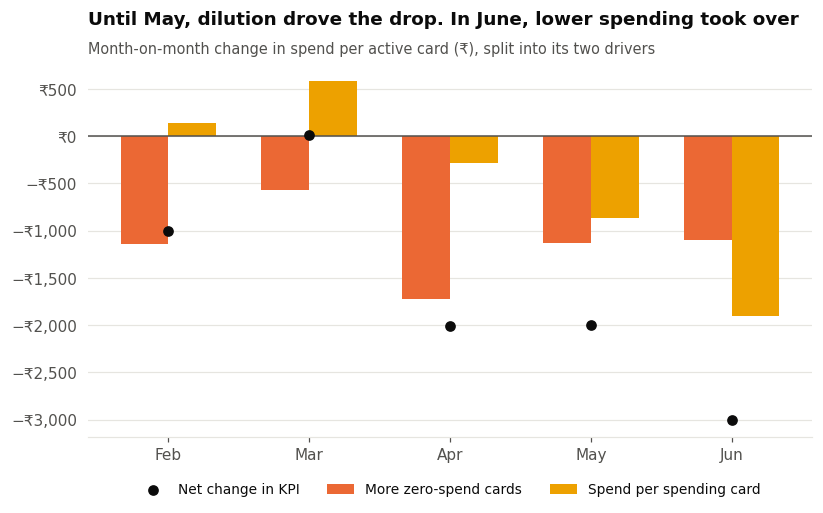

month,zero_spend_dilution,lower_spend_per_spending_card,total_change
Feb,"₹-1,138",₹138,"₹-1,000"
Mar,₹-573,₹584,₹11
Apr,"₹-1,725",₹-286,"₹-2,011"
May,"₹-1,136",₹-864,"₹-2,000"
Jun,"₹-1,101","₹-1,899","₹-3,000"


In [7]:
mb = M.monthly_bridge(pm)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(mb))
w = 0.34
ax.bar(x - w/2, mb.zero_spend_dilution, w, color=P.ORANGE, label="More zero-spend cards")
ax.bar(x + w/2, mb.lower_spend_per_spending_card, w, color=P.YELLOW, label="Spend per spending card")
ax.scatter(x, mb.total_change, color=P.INK, zorder=3, s=36, label="Net change in KPI")
ax.axhline(0, color=P.INK_2, lw=1)
ax.set_xticks(x, mb.month.astype(str))
P.inr_axis(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=3, fontsize=9)
ax.set_title("Until May, dilution drove the drop. In June, lower spending took over", pad=26)
P.subtitle(ax, "Month-on-month change in spend per active card (₹), split into its two drivers")
P.save(fig, "fig3_monthly_bridge"); plt.show()
mb.style.format({c: "₹{:,.0f}" for c in mb.columns if c != "month"}).hide(axis="index")

**What this shows**

* **69% of the total drop** is dilution: cards counted as active that spent nothing. That's mechanical. The KPI's denominator grew, not customers spending less.
* The other **31%** is lower spend among cards that do spend. But it's concentrated in **May and June**: June alone accounts for about ₹1,900. This needs watching, not panic. Six months of data can't separate a trend from seasonality.

## 3. Who are the zero-spend cards? (June card-age view)

If dilution is the story, the new cards should be where the zero-spend cards sit.

In [8]:
vm = M.vintage_metrics(t3)
vm[["vintage", "pct_cards", "avg_spend_inr", "median_spend_inr", "spend_share"]].style.format(
    {"pct_cards": "{:.0f}%", "avg_spend_inr": "₹{:,.0f}", "median_spend_inr": "₹{:,.0f}",
     "spend_share": "{:.0%}"}).hide(axis="index")

vintage,pct_cards,avg_spend_inr,median_spend_inr,spend_share
< 3 months,28%,"₹2,100",₹0,13%
3 - 6 months,17%,"₹3,900","₹1,800",15%
6 - 12 months,17%,"₹5,200","₹3,600",20%
> 12 months,38%,"₹6,300","₹4,900",53%


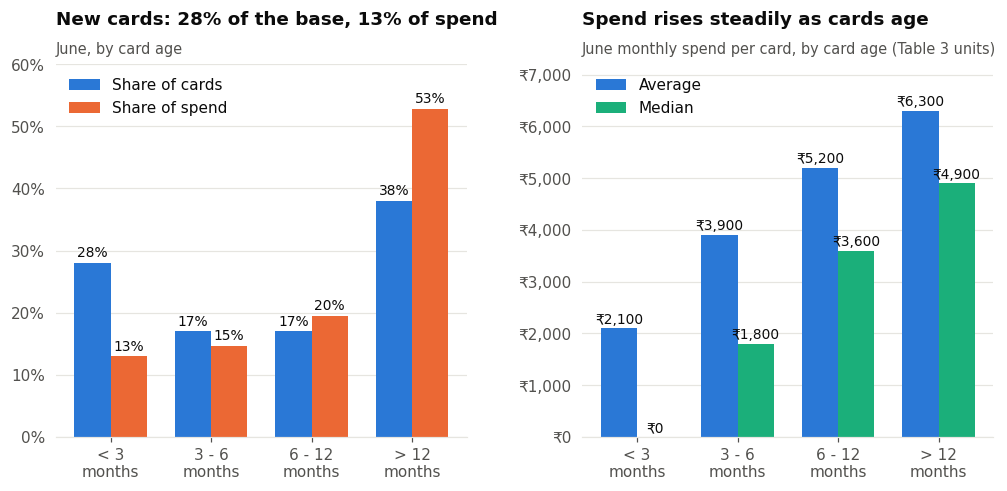

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={"wspace": 0.28})
x = np.arange(len(vm)); w = 0.36
a1.bar(x - w/2, vm.card_share, w, color=P.BLUE, label="Share of cards")
a1.bar(x + w/2, vm.spend_share, w, color=P.ORANGE, label="Share of spend")
for i, r in vm.iterrows():
    a1.text(i - w/2, r.card_share + 0.01, f"{r.card_share:.0%}", ha="center", fontsize=9)
    a1.text(i + w/2, r.spend_share + 0.01, f"{r.spend_share:.0%}", ha="center", fontsize=9)
a1.set_xticks(x, vm.vintage.str.replace(" months", "\nmonths")); P.pct_axis(a1); a1.set_ylim(0, 0.6); a1.legend(loc="upper left")
a1.set_title("New cards: 28% of the base, 13% of spend", pad=26)
P.subtitle(a1, "June, by card age")

a2.bar(x - w/2, vm.avg_spend_inr, w, color=P.BLUE, label="Average")
a2.bar(x + w/2, vm.median_spend_inr, w, color=P.AQUA, label="Median")
for i, r in vm.iterrows():
    a2.text(i - w/2, r.avg_spend_inr + 100, P.inr(r.avg_spend_inr), ha="center", fontsize=9)
    a2.text(i + w/2, r.median_spend_inr + 100, P.inr(r.median_spend_inr), ha="center", fontsize=9)
a2.set_xticks(x, vm.vintage.str.replace(" months", "\nmonths")); P.inr_axis(a2); a2.set_ylim(0, 7200); a2.legend(loc="upper left")
a2.set_title("Spend rises steadily as cards age", pad=26)
P.subtitle(a2, "June monthly spend per card, by card age (Table 3 units)")
P.save(fig, "fig4_vintage"); plt.show()

In [10]:
floor = M.new_card_zero_spend_floor(t3, pm)
floor.to_frame("value").style.format(lambda v: f"{v:.0%}" if v < 1.5 else f"{v:,.0f}")

,value
june_new_cards,"322,000"
june_zero_spend_cards,"253,000"
min_zero_spend_new_cards,"161,000"
min_share_of_zero_spend_from_new,64%
jan_to_jun_increase_in_zero_spend,"154,600"


In [11]:
scen, seasoned_avg, actual = M.vintage_mix_scenarios(t3)
print(f"June average, all cards: ₹{actual:,.0f}   |   cards older than 3 months only: ₹{seasoned_avg:,.0f} "
      f"(+{seasoned_avg/actual-1:.0%})")
scen.style.format({"new_card_share": "{:.0%}", "portfolio_avg": "₹{:,.0f}", "vs_june_actual": "{:+.1%}"}).hide(axis="index")

June average, all cards: ₹4,529   |   cards older than 3 months only: ₹5,474 (+21%)


new_card_share,portfolio_avg,vs_june_actual
0%,"₹5,474",+20.9%
15%,"₹4,968",+9.7%
20%,"₹4,799",+6.0%
28%,"₹4,529",+0.0%


**What this shows**

* The under-3-month cohort's median spend is ₹0, so **at least half of the 322K new cards spent nothing in June**. That's at least 161K cards, or **at least 64% of all zero-spend cards**. It's also more than the entire Jan→Jun rise in zero-spend cards (+155K).
* Spend rises steadily with card age (₹2.1K → ₹3.9K → ₹5.2K → ₹6.3K). New cards haven't "gone bad"; they simply haven't **ramped up yet**.
* **Mix effect alone:** keeping each cohort's spend fixed, a base with 15–20% new cards (roughly what January's acquisition pace implies) would average **6–10% higher** than June's actual. In June, cards older than 3 months average **21% more** than the blended figure.

## 4. Category mix: a real but secondary shift

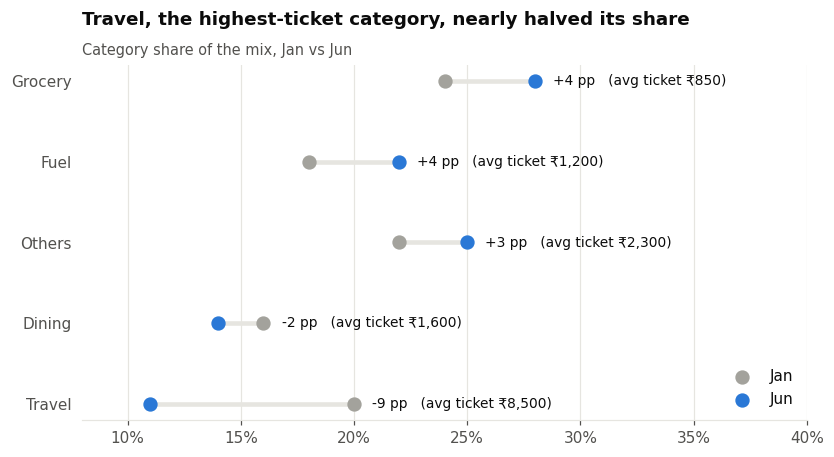

In [12]:
cm = M.category_mix(t4).sort_values("share_change_pp")
fig, ax = plt.subplots(figsize=(8.5, 4.2))
y = np.arange(len(cm))
for i, r in enumerate(cm.itertuples()):
    ax.plot([r.jan_share_pct, r.jun_share_pct], [i, i], color=P.GRID, lw=3, zorder=1)
ax.scatter(cm.jan_share_pct, y, color=P.GREY, s=70, zorder=2, label="Jan")
ax.scatter(cm.jun_share_pct, y, color=P.BLUE, s=70, zorder=3, label="Jun")
for i, r in enumerate(cm.itertuples()):
    ax.text(max(r.jan_share_pct, r.jun_share_pct) + 0.8, i, f"{r.share_change_pp:+d} pp   (avg ticket ₹{r.avg_ticket_inr:,})",
            va="center", fontsize=9, color=P.INK)
ax.set_yticks(y, cm.category); ax.set_xlim(8, 40)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.grid(axis="x", color=P.GRID); ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("Travel, the highest-ticket category, nearly halved its share", pad=26)
P.subtitle(ax, "Category share of the mix, Jan vs Jun")
P.save(fig, "fig5_category_mix"); plt.show()

In [13]:
M.ticket_weighted_average(t4).to_frame("value").style.format(lambda v: f"{v:+.1%}" if abs(v) < 1 else f"₹{v:,.0f}")

,value
jan_avg_ticket,"₹2,882"
jun_avg_ticket,"₹2,236"
change,-22.4%


**What this shows**

* Travel (₹8,500 average ticket, about 5–10× other categories) fell from 20% to 11%. Grocery and fuel (₹850–₹1,200) gained.
* **If** the shares are shares of *transactions*, this mix shift alone cuts the average ticket by about **22%**. That matches the timing of the May–June softening in spend per spending card.
* This shift is consistent with two explanations little difficult to tell apart:
  1. **Seasonality / travel demand:** a real, external change.
  2. **New-customer profile:** new cards skew towards everyday categories, so the mix shifts as they join. That would make this partly mechanical too.

  Splitting category mix by card age would settle it.

## 5. Data checks: the tables don't fully reconcile

Before presenting any number to leadership, we check that the tables agree with each other.

In [14]:
cc = M.consistency_checks(pm, t2, t3)
cc.style.format({"june_avg_spend_inr": "₹{:,.0f}", "ratio_to_table3": "{:.1f}×"}).hide(axis="index")

source,june_avg_spend_inr,type,ratio_to_table3
Table 1: total spend / active cards,"₹42,000",exact,9.3×
Table 2: lowest average the buckets allow,"₹5,750",lower bound,1.3×
Table 3: card-weighted vintage average,"₹4,529",exact,1.0×


In [15]:
M.cohort_count_check(pm, t3).to_frame("cards").style.format("{:,.0f}")

,cards
cards_added_apr_jun,"385,000"
t3_new_cards_in_active_base,"322,000"
gap,"63,000"


In [16]:
pm[["month", "new_cards_added_k", "implied_cards_exited"]].assign(
    implied_cards_exited_k=lambda d: d.implied_cards_exited / 1000).drop(columns="implied_cards_exited") \
    .style.format({"implied_cards_exited_k": "{:,.0f}"}, na_rep="–").hide(axis="index")

month,new_cards_added_k,implied_cards_exited_k
Jan,60,–
Feb,75,45
Mar,95,35
Apr,110,40
May,130,50
Jun,145,55


**Concerns with the data** (none of them change the direction of the conclusion):

1. **Units mismatch.** Table 1 implies about **₹42,000** per active card in June. Table 3 implies **₹4,529**, about 9× lower. Table 2's buckets imply **at least ₹5,750**, which is *above* Table 3's average. Is Table 1 total spend quarterly, or in a different unit? Do Tables 2 and 3 use a different definition of "active"? The analysis above uses each table only for **relative** comparisons (shares, % changes), so the conclusions hold either way.
2. **385K cards were added in April–June, but Table 3 shows only 322K under-3-month cards in the active base.** So about 63K new cards may not count as "active" at all. If so, the activation problem is bigger than Table 1 shows.
3. **About 225K cards left the active base** (previous month's active + new − current active) over five months, roughly 4–5% a month. Are these closures, or cards dropping out of an "active" definition? This needs its own investigation.
4. **Category shares:** are they shares of spend value or of transaction count? That decides whether the 22% ticket effect is real.

## 6. Answers

### Q1. Is the spend decline real or mechanical?

**Mostly mechanical, with a smaller real component that started recently.**

| Evidence | Reading |
|---|---|
| Total spend **+18%** while spend per active card is **−16%** | The business is growing; the KPI's denominator grew faster |
| Active cards **+40%**; zero-spend share **12% → 22%** | New cards enter the denominator before they spend |
| **69%** of the ₹8,000 drop is zero-spend dilution | Mechanical |
| Spend per spending card **−5%**, flat until April, then down in May–June | Real, and possibly partly mix (new low-spend activators, travel decline) |

### Q2. The single biggest driver

**Rapid new-card acquisition, with cards slow to activate.** New cards are 28% of the base, contribute 13% of spend, and have a median spend of ₹0. They account for at least 64% of zero-spend cards, which by themselves explain about 70% of the decline.

### Q3. CEO summary: see `reports/CEO_summary.pptx`

**Headline:** *Customers aren't spending less. Cards are being added faster than they activate.*

**Recommended actions**

1. **Fix activation in the first 90 days:** a first-transaction incentive, nudges in the first 30 days, and activation targets for each acquisition channel. Every point of zero-spend share recovered is worth about ₹540 on the KPI (1% × ₹53.8K spend per spending card).
2. **Change how the KPI is reported:** show spend per *spending* card and per *vintage cohort* next to the blended average, so growth stops looking like decline.
3. **Watch the real signal:** track May–June spend per spending card and the travel share monthly. Compare with last year's season before running a travel campaign.
4. **Data requests:** cohort-level monthly spend (same cards, Jan vs Jun), category mix by card age, and one shared definition of "active".

### Assumptions and limitations

* Six monthly snapshots can't separate seasonality from trend. A year-on-year comparison is needed.
* Tables 3 and 2 are June-only, so the vintage mix effect for January is estimated from the acquisition pace.
* Unit inconsistencies between tables are flagged above. All conclusions rely on relative measures, which are robust to them.